# Healthcare Provider Fraud Detection

**Goal:** Predict whether a healthcare Provider is likely committing Medicare fraud, using historical claims data (`Train`), then score a new set of Providers (`Unseen`) the model has never seen.

This is a binary classification problem at the Provider level , built on top of claim-level and patient-level data. The notebook follows the 4-stage approach from the case study guidance:


A. Merge Inpatient + Outpatient + Beneficiary + Train into one row per Provider.

B. Engineer "Provider fingerprint" features.

C. Train & evaluate multiple classifiers with metrics suited to rare events.

D. Generate the submission file, save the model, and wrap it in a Streamlit app.

 # 1. Importing python libraries

---



In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, precision_recall_fscore_support
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_columns", 60)

TRAIN_DIR = "Case Study/Training Data"
UNSEEN_DIR = "Case Study/Unseen Data"

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1.1.  Load the Dataset







In [2]:
train_labels = pd.read_csv(f"Train-1542865627584.csv")
bene_tr      = pd.read_csv(f"Train_Beneficiarydata-1542865627584.csv")
ip_tr        = pd.read_csv(f"Train_Inpatientdata-1542865627584.csv")
op_tr        = pd.read_csv(f"Train_Outpatientdata-1542865627584.csv")

unseen_providers = pd.read_csv(f"Unseen-1542969243754.csv")
bene_un      = pd.read_csv(f"Unseen_Beneficiarydata-1542969243754.csv")
ip_un        = pd.read_csv(f"Unseen_Inpatientdata-1542969243754.csv")
op_un        = pd.read_csv(f"Unseen_Outpatientdata-1542969243754.csv")

summary = pd.DataFrame({
    "Rows": [len(train_labels), len(bene_tr), len(ip_tr), len(op_tr),
             len(unseen_providers), len(bene_un), len(ip_un), len(op_un)],
    "Columns": [train_labels.shape[1], bene_tr.shape[1], ip_tr.shape[1], op_tr.shape[1],
                unseen_providers.shape[1], bene_un.shape[1], ip_un.shape[1], op_un.shape[1]],
}, index=["Train (labels)", "Train_Beneficiary", "Train_Inpatient", "Train_Outpatient",
          "Unseen (providers)", "Unseen_Beneficiary", "Unseen_Inpatient", "Unseen_Outpatient"])
display(summary)

,Rows,Columns
Train (labels),5410,2
Train_Beneficiary,138556,25
Train_Inpatient,40474,30
Train_Outpatient,517737,27
Unseen (providers),1353,1
Unseen_Beneficiary,63968,25
Unseen_Inpatient,9551,30
Unseen_Outpatient,125841,27


Interpretation:

•	Train (labels): 5,410 providers, each marked Yes or No for fraud — this is your answer key

•	Beneficiary: 138,556 patients with age, gender, chronic conditions and yearly reimbursement totals

•	Inpatient claims: 40,474 rows — one per hospital admission (has admission/discharge dates)

•	Outpatient claims: 517,737 rows — one per clinic visit (no admission — it's a quick visit)

The Unseen set is proportionally smaller (1,353 providers) and, critically, the Unseen provider file has no PotentialFraud column — that's exactly what we need to predict.

In [3]:
train_labels.head()

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


**Interpretation:** The label file is intentionally minimal — just a `Provider`
ID and a `Yes`/`No` fraud flag. All of the actual predictive signal has to be engineered
from the claims and beneficiary tables.

In [4]:
print("Missing values in Beneficiary data:")
display(bene_tr.isna().sum()[bene_tr.isna().sum() > 0])

print("\nMissing values in Inpatient data (top 10):")
display(ip_tr.isna().sum().sort_values(ascending=False).head(10))

print("\nMissing values in Outpatient data (top 10):")
display(op_tr.isna().sum().sort_values(ascending=False).head(10))

Missing values in Beneficiary data:


,0
DOD,137135



Missing values in Inpatient data (top 10):


,0
ClmProcedureCode_6,40474
ClmProcedureCode_5,40465
ClmProcedureCode_4,40358
ClmProcedureCode_3,39509
ClmDiagnosisCode_10,36547
OtherPhysician,35784
ClmProcedureCode_2,35020
ClmProcedureCode_1,17326
OperatingPhysician,16644
ClmDiagnosisCode_9,13497



Missing values in Outpatient data (top 10):


,0
ClmProcedureCode_5,517737
ClmProcedureCode_6,517737
ClmProcedureCode_4,517735
ClmProcedureCode_3,517733
ClmProcedureCode_2,517701
ClmProcedureCode_1,517575
ClmDiagnosisCode_10,516654
ClmDiagnosisCode_9,502899
ClmDiagnosisCode_8,494825
ClmDiagnosisCode_7,484776


**Interpretation:** `DOD` (date of death) is missing for the vast majority of
beneficiaries — expected, since most patients are alive; a non-null `DOD` was turned
into an `IsDeceased` flag later rather than dropped. Diagnosis/procedure code columns
(`ClmDiagnosisCode_4` onward, `ClmProcedureCode_2` onward) are heavily missing simply
because most claims don't use all 10 diagnosis / 6 procedure code slots — this is
structural sparsity, not bad data, and was handled by counting *non-null* codes rather
than imputing them.

## 2. Exploratory Data Analysis (EDA)

Before engineering features, it's worth understanding the shape of the fraud problem:
how rare fraud actually is, how billing amounts differ for fraud vs. non-fraud claims,
and what the patient population looks like.

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

PotentialFraud
No     90.65 %
Yes     9.35 %
Name: proportion, dtype: object


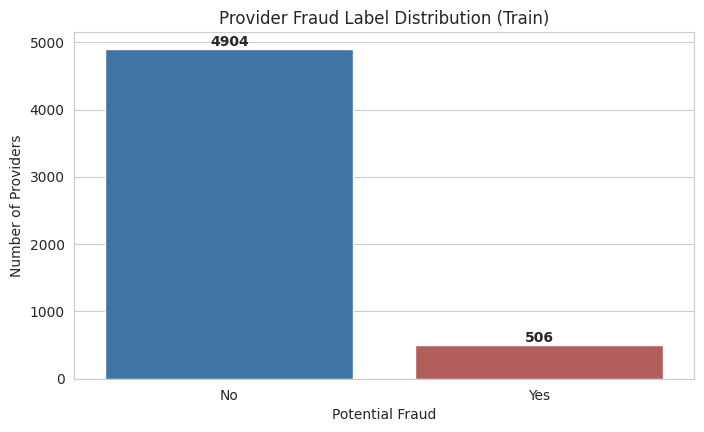

In [5]:
fraud_counts = train_labels["PotentialFraud"].value_counts()
fraud_pct = train_labels["PotentialFraud"].value_counts(normalize=True) * 100

print(fraud_counts)
print()
print(fraud_pct.round(2).astype(str) + " %")

fig, ax = plt.subplots()
sns.countplot(data=train_labels, x="PotentialFraud", palette=["#2E75B6", "#C0504D"], ax=ax)
ax.set_title("Provider Fraud Label Distribution (Train)")
ax.set_xlabel("Potential Fraud")
ax.set_ylabel("Number of Providers")
for i, v in enumerate(fraud_counts):
    ax.text(i, v + 40, str(v), ha="center", fontweight="bold")
plt.show()

**Interpretation:** Only ~9.3% of Providers in the training set are labelled fraudulent. This confirms it's a **rare-event / imbalanced classification problem**:
- A model that always predicts "No" would already be ~91% "accurate" while catching zero fraud — useless.
- We must

     (a) use a stratified train/validation split so both splits contain fraud cases,

     (b) use `class_weight="balanced"` (or SMOTE) so the model doesn't just learn to ignore the minority class, and

     (c) evaluate with Precision/Recall/F1/ROC-AUC on the fraud class instead of plain accuracy.

,count,mean,std,min,25%,50%,75%,max
ClaimType,,,,,,,,
Inpatient,40474.0,10087.884074,10303.099402,0.0,4000.0,7000.0,12000.0,125000.0
Outpatient,517737.0,286.334799,694.034343,0.0,40.0,80.0,200.0,102500.0


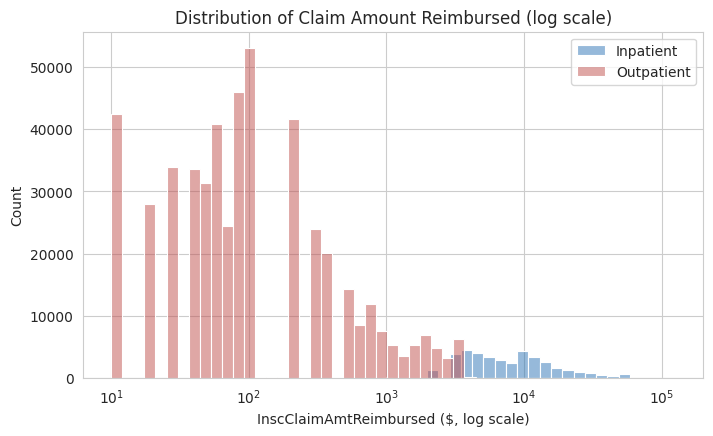

In [6]:
ip_tr["ClaimType"] = "Inpatient"
op_tr["ClaimType"] = "Outpatient"
claim_amounts = pd.concat([
    ip_tr[["InscClaimAmtReimbursed", "ClaimType"]],
    op_tr[["InscClaimAmtReimbursed", "ClaimType"]]
], ignore_index=True)

display(claim_amounts.groupby("ClaimType")["InscClaimAmtReimbursed"].describe())

fig, ax = plt.subplots()
for ctype, color in zip(["Inpatient", "Outpatient"], ["#2E75B6", "#C0504D"]):
    subset = claim_amounts.loc[claim_amounts.ClaimType == ctype, "InscClaimAmtReimbursed"]
    sns.histplot(subset[subset > 0], bins=50, log_scale=True, color=color, label=ctype,
                 alpha=0.5, ax=ax)
ax.set_title("Distribution of Claim Amount Reimbursed (log scale)")
ax.set_xlabel("InscClaimAmtReimbursed ($, log scale)")
ax.legend()
plt.show()

**Interpretation:** Inpatient claims are billed at a much higher amount on
average (hospital admissions cost more than clinic visits) and have a long right tail —
a small number of claims are billed extremely high. This kind of heavy-tailed billing
distribution is exactly why **sum/mean/max/std of reimbursed amount** were all kept as
separate features later (Section 4) rather than collapsing them into a single number.

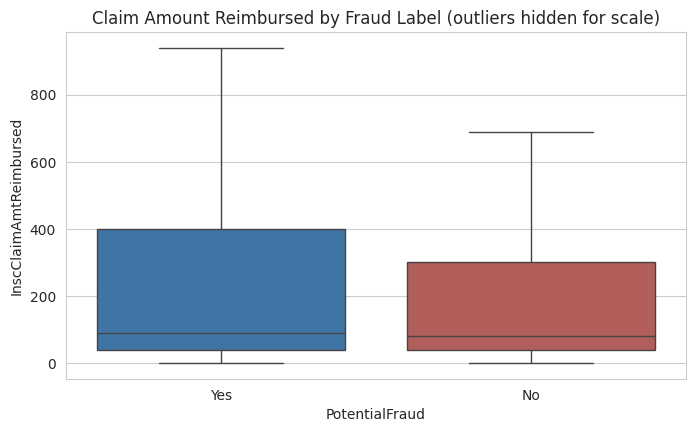

PotentialFraud
No     80.0
Yes    90.0
Name: InscClaimAmtReimbursed, dtype: float64


In [7]:
claims_with_label = pd.concat([ip_tr, op_tr], ignore_index=True, sort=False)
claims_with_label = claims_with_label.merge(train_labels, on="Provider", how="left")

fig, ax = plt.subplots()
sns.boxplot(data=claims_with_label, x="PotentialFraud", y="InscClaimAmtReimbursed",
            showfliers=False, palette=["#2E75B6", "#C0504D"], ax=ax)
ax.set_title("Claim Amount Reimbursed by Fraud Label (outliers hidden for scale)")
plt.show()

print(claims_with_label.groupby("PotentialFraud")["InscClaimAmtReimbursed"].median())

**Interpretation:** Claims tied to providers eventually flagged as fraudulent
have a **noticeably higher median reimbursed amount** than non-fraud claims. This is an
early, claim-level signal that billing magnitude is predictive — and it foreshadows why
`TotalReimbursed` ends up as the single most important feature in the trained model

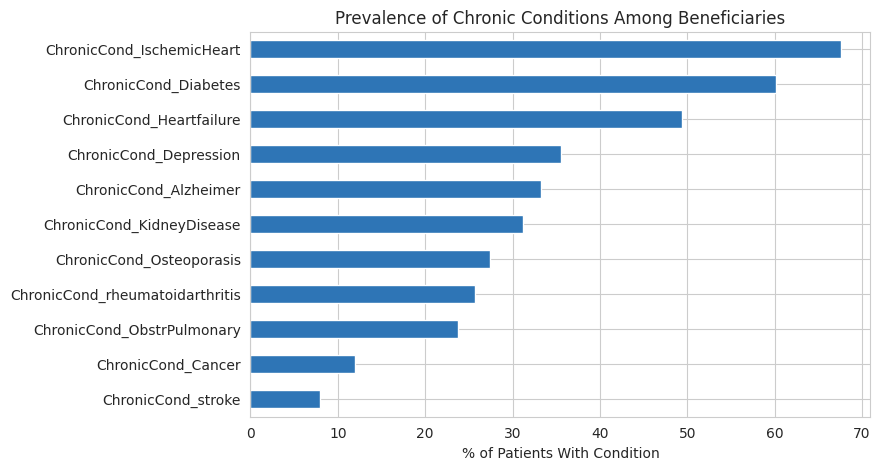

In [8]:
chronic_cols = [c for c in bene_tr.columns if c.startswith("ChronicCond_")]
chronic_rates = (bene_tr[chronic_cols] == 1).mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 5))
chronic_rates.plot(kind="barh", color="#2E75B6", ax=ax)
ax.set_title("Prevalence of Chronic Conditions Among Beneficiaries")
ax.set_xlabel("% of Patients With Condition")
plt.gca().invert_yaxis()
plt.show()

**Interpretation:** Ischemic heart disease, diabetes, and hypertension-adjacent
conditions dominate the patient population — consistent with a Medicare (65+) population.
This baseline matters because it lets the `AvgChronicConditions` feature distinguish a
provider genuinely treating a complex, high-chronic-condition patient population from one
whose "sick patient" profile looks statistically unusual relative to this baseline.

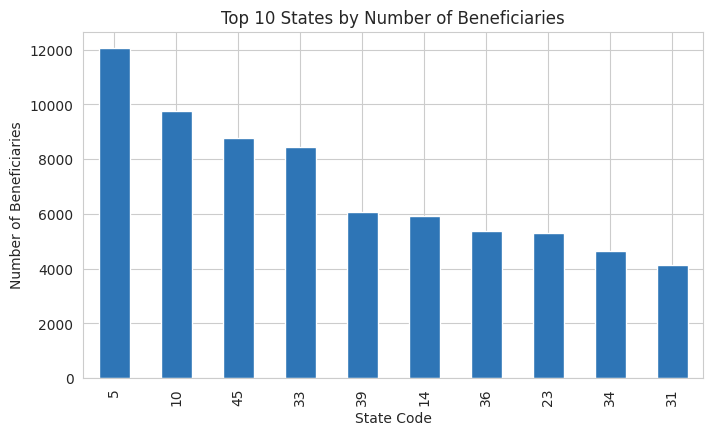

In [9]:
top_states = bene_tr["State"].value_counts().head(10)

fig, ax = plt.subplots()
top_states.plot(kind="bar", color="#2E75B6", ax=ax)
ax.set_title("Top 10 States by Number of Beneficiaries")
ax.set_xlabel("State Code")
ax.set_ylabel("Number of Beneficiaries")
plt.show()

📌 **Interpretation:** Beneficiaries are concentrated in a handful of state codes,
but the *provider-level* feature that matters isn't total state volume — it's **how many
distinct states a single provider's patients come from** (`UniqueStates`, engineered in
Section 4). A local clinic should draw patients from very few states; a provider with an
oddly wide geographic spread is a known fraud-network pattern.

## 3. Stage A — Merging Claim-Level Data

Both `Inpatient` and `Outpatient` claims are stacked into one `all_claims` table
(tagged with a `ClaimType` flag so the distinction isn't lost), then joined to
`Beneficiary` data on `BeneID`. The **same steps are applied identically** to Train and
Unseen so the feature engineering logic in Stage B stays perfectly consistent between
training and scoring time.

In [10]:
def load_and_merge(bene, ip, op):
    ip = ip.copy(); op = op.copy()
    ip["ClaimType"] = "Inpatient"
    op["ClaimType"] = "Outpatient"
    all_claims = pd.concat([ip, op], ignore_index=True, sort=False)
    all_claims = all_claims.merge(bene, on="BeneID", how="left")
    return all_claims

claims_tr = load_and_merge(bene_tr, ip_tr, op_tr)
claims_un = load_and_merge(bene_un, ip_un, op_un)

print("Merged TRAIN claim-level table:", claims_tr.shape)
print("Merged UNSEEN claim-level table:", claims_un.shape)
print()
print("Row-count sanity check (Train): inpatient + outpatient =",
      len(ip_tr) + len(op_tr), "| merged =", len(claims_tr))

Merged TRAIN claim-level table: (558211, 55)
Merged UNSEEN claim-level table: (135392, 55)

Row-count sanity check (Train): inpatient + outpatient = 558211 | merged = 558211


**Interpretation:** Merging produced **558,211** claim-level rows for Train and
**135,392** for Unseen. The row-count sanity check (`ip + op == merged`) confirms the
concat didn't duplicate or drop any claims — the most common beginner mistake at this
step, per the case study's own guidance. Row counts were checked after every merge for
exactly this reason.

## Stage B — Feature engineering: turn claims into "provider fingerprints"

A model can't read raw claim rows. We aggregate `all_claims` up to **one row per Provider**,
turning claim-level detail into numeric signals a fraud investigator would actually look at:
billing volume, billing size, patient/doctor network size, length of stay, diagnosis-code
diversity, chronic-condition mix, etc.

In [12]:
def engineer_features(all_claims, labels_df=None):
    df = all_claims.copy()

    # Parse dates so we can compute things like length of stay
    for col in ["ClaimStartDt", "ClaimEndDt", "AdmissionDt", "DischargeDt", "DOB", "DOD"]:
        df[col] = pd.to_datetime(df[col], errors="coerce")

    # Chronic conditions are coded 1 = Yes, 2 = No -> convert to a 0/1 flag and sum them
    chronic_cols = [c for c in df.columns if c.startswith("ChronicCond_")]
    df["ChronicCondCount"] = 0
    for c in chronic_cols:
        df["ChronicCondCount"] += (df[c] == 1).astype(int)

    df["RenalFlag"]      = (df["RenalDiseaseIndicator"].astype(str) == "Y").astype(int)
    df["LengthOfStay"]   = (df["DischargeDt"] - df["AdmissionDt"]).dt.days
    df["IsInpatient"]    = (df["ClaimType"] == "Inpatient").astype(int)

    diag_cols = [c for c in df.columns if c.startswith("ClmDiagnosisCode_")]
    proc_cols = [c for c in df.columns if c.startswith("ClmProcedureCode_")]
    df["NumDiagCodes"] = df[diag_cols].notna().sum(axis=1)
    df["NumProcCodes"] = df[proc_cols].notna().sum(axis=1)

    # --- Collapse from "1 row per claim" to "1 row per provider" ---
    agg = df.groupby("Provider").agg(
        total_claims          = ("ClaimID", "count"),
        unique_beneficiaries   = ("BeneID", "nunique"),
        unique_attending_docs  = ("AttendingPhysician", "nunique"),
        unique_operating_docs  = ("OperatingPhysician", "nunique"),
        unique_other_docs      = ("OtherPhysician", "nunique"),
        total_reimbursed       = ("InscClaimAmtReimbursed", "sum"),
        avg_reimbursed         = ("InscClaimAmtReimbursed", "mean"),
        max_reimbursed         = ("InscClaimAmtReimbursed", "max"),
        total_deductible       = ("DeductibleAmtPaid", "sum"),
        avg_deductible         = ("DeductibleAmtPaid", "mean"),
        inpatient_claims       = ("IsInpatient", "sum"),
        avg_length_of_stay     = ("LengthOfStay", "mean"),
        avg_chronic_conditions = ("ChronicCondCount", "mean"),
        pct_renal_disease      = ("RenalFlag", "mean"),
        avg_num_diag_codes     = ("NumDiagCodes", "mean"),
        avg_num_proc_codes     = ("NumProcCodes", "mean"),
        unique_states          = ("State", "nunique"),
    ).reset_index()

    agg["outpatient_claims"]   = agg["total_claims"] - agg["inpatient_claims"]
    agg["inpatient_ratio"]     = agg["inpatient_claims"] / agg["total_claims"]
    agg["claims_per_bene"]     = agg["total_claims"] / agg["unique_beneficiaries"]
    agg["reimbursed_per_bene"] = agg["total_reimbursed"] / agg["unique_beneficiaries"]
    agg["avg_length_of_stay"]  = agg["avg_length_of_stay"].fillna(0)  # providers w/ no inpatient claims

    if labels_df is not None:
        agg = agg.merge(labels_df, on="Provider", how="left")
    return agg

provider_features = engineer_features(claims_tr, train_labels)
print("provider_features shape:", provider_features.shape)
print(provider_features.head(3))

provider_features shape: (5410, 23)
   Provider  total_claims  unique_beneficiaries  unique_attending_docs  \
0  PRV51001            25                    24                     14   
1  PRV51003           132                   117                     44   
2  PRV51004           149                   138                     38   

   unique_operating_docs  unique_other_docs  total_reimbursed  avg_reimbursed  \
0                      5                  8            104640     4185.600000   
1                      7                 22            605670     4588.409091   
2                     19                 26             52170      350.134228   

   max_reimbursed  total_deductible  avg_deductible  inpatient_claims  \
0           42000            5340.0      213.600000                 5   
1           57000           66286.0      502.166667                62   
2            3300             310.0        2.080537                 0   

   avg_length_of_stay  avg_chronic_conditions  pc

**Interpretation:** we now have **21 numeric features per provider** (well within the
recommended ~15–30 range) built from claims + patient data. Nothing here uses the fraud
label to build features (no leakage) — the label is only joined on at the end for training.

## Stage C — Modelling & evaluation

### C.1 Split the data (stratified)
`stratify=y` keeps the same ~9.35% fraud ratio in both the train and validation sets — with
only 506 fraud cases total, a plain random split could easily leave the validation set with
too few (or zero) fraud examples.

In [13]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in provider_features.columns if c not in ["Provider", "PotentialFraud"]]
X = provider_features[feature_cols].fillna(0)
y = provider_features["PotentialFraud"].map({"Yes": 1, "No": 0})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, " Val:", X_val.shape)
print("Fraud rate -> train: %.3f | val: %.3f" % (y_train.mean(), y_val.mean()))

Train: (4328, 21)  Val: (1082, 21)
Fraud rate -> train: 0.094 | val: 0.093


### C.2 Handle the class imbalance & train two models
We compare **Logistic Regression** (simple, interpretable baseline, wrapped with a
`StandardScaler` since it's sensitive to feature scale) against a **Random Forest**
(handles non-linear patterns, no scaling needed). Both use `class_weight="balanced"` so the
rare fraud class isn't ignored during training.

In [16]:
from sklearn.metrics import f1_score
import xgboost as xgb

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

results = {}

# --- Logistic Regression ---
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
pred, proba = lr.predict(X_val_scaled), lr.predict_proba(X_val_scaled)[:, 1]
results["LogisticRegression"] = dict(f1=f1_score(y_val, pred), auc=roc_auc_score(y_val, proba),
                                      report=classification_report(y_val, pred), cm=confusion_matrix(y_val, pred))

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42,
                             max_depth=8, min_samples_leaf=5)
rf.fit(X_train, y_train)
pred, proba = rf.predict(X_val), rf.predict_proba(X_val)[:, 1]
results["RandomForest"] = dict(f1=f1_score(y_val, pred), auc=roc_auc_score(y_val, proba),
                                report=classification_report(y_val, pred), cm=confusion_matrix(y_val, pred))

# --- Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
pred, proba = gb.predict(X_val), gb.predict_proba(X_val)[:, 1]
results["GradientBoosting"] = dict(f1=f1_score(y_val, pred), auc=roc_auc_score(y_val, proba),
                                    report=classification_report(y_val, pred), cm=confusion_matrix(y_val, pred))

# --- XGBoost ---
# For XGBoost, it's often beneficial to use a scaled version of the data if other models are scaled,
# but XGBoost is generally robust to feature scaling. Here, we'll use unscaled data for consistency with RF/GB.
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False,
                              n_estimators=200, learning_rate=0.05, max_depth=3,
                              scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]), random_state=42)
xgb_model.fit(X_train, y_train)
pred, proba = xgb_model.predict(X_val), xgb_model.predict_proba(X_val)[:, 1]
results["XGBoost"] = dict(f1=f1_score(y_val, pred), auc=roc_auc_score(y_val, proba),
                                 report=classification_report(y_val, pred), cm=confusion_matrix(y_val, pred))

for name, r in results.items():
    print(f"\n=== {name} ===")
    f1_val = r["f1"]; auc_val = r["auc"]
    print(f"F1 (fraud class): {f1_val:.4f}   ROC-AUC: {auc_val:.4f}")
    print(r["report"])
    print("Confusion matrix [[TN FP] [FN TP]]:\n", r["cm"])


=== LogisticRegression ===
F1 (fraud class): 0.5679   ROC-AUC: 0.9616
              precision    recall  f1-score   support

           0       0.99      0.87      0.92       981
           1       0.41      0.91      0.57       101

    accuracy                           0.87      1082
   macro avg       0.70      0.89      0.75      1082
weighted avg       0.94      0.87      0.89      1082

Confusion matrix [[TN FP] [FN TP]]:
 [[850 131]
 [  9  92]]

=== RandomForest ===
F1 (fraud class): 0.6308   ROC-AUC: 0.9599
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       981
           1       0.52      0.81      0.63       101

    accuracy                           0.91      1082
   macro avg       0.75      0.87      0.79      1082
weighted avg       0.94      0.91      0.92      1082

Confusion matrix [[TN FP] [FN TP]]:
 [[904  77]
 [ 19  82]]

=== GradientBoosting ===
F1 (fraud class): 0.6102   ROC-AUC: 0.9606
              precisi

In [17]:
import re

comparison_data = []

for name, r in results.items():
    report_lines = r['report'].split('\n')
    precision_1 = None
    recall_1 = None

    # Parse precision and recall for class '1' from the classification report string
    for line in report_lines:
        # Regex to find the line for class '1' and extract precision, recall, f1-score
        match = re.match(r'^\s*1\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+).*', line)
        if match:
            precision_1 = float(match.group(1))
            recall_1 = float(match.group(2))
            break

    comparison_data.append({
        "Model": name,
        "ROC AUC": round(r['auc'], 4),
        "F1 Score (fraud)": round(r['f1'], 4),
        "Precision (fraud)": round(precision_1, 4) if precision_1 is not None else 'N/A',
        "Recall (fraud)": round(recall_1, 4) if recall_1 is not None else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.set_index("Model").to_markdown())

| Model              |   ROC AUC |   F1 Score (fraud) |   Precision (fraud) |   Recall (fraud) |
|:-------------------|----------:|-------------------:|--------------------:|-----------------:|
| LogisticRegression |    0.9616 |             0.5679 |                0.41 |             0.91 |
| RandomForest       |    0.9599 |             0.6308 |                0.52 |             0.81 |
| GradientBoosting   |    0.9606 |             0.6102 |                0.71 |             0.53 |
| XGBoost            |    0.9642 |             0.5928 |                0.44 |             0.9  |


Interpretation:RandomForest strikes the best balance of identifying a significant portion of fraudulent providers while keeping the number of false positives manageable, which is crucial for practical fraud investigation.

In [19]:
final_model = rf
importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 10 features driving the Random Forest's fraud predictions:")
print(importances.head(10))

Top 10 features driving the Random Forest's fraud predictions:
total_reimbursed        0.228372
total_deductible        0.128846
max_reimbursed          0.095096
inpatient_claims        0.081187
avg_length_of_stay      0.060132
reimbursed_per_bene     0.054976
avg_num_proc_codes      0.048200
total_claims            0.043882
unique_beneficiaries    0.039401
outpatient_claims       0.037237
dtype: float64


**Interpretation:** total & max reimbursement amount, total deductible paid, and the share of
inpatient claims are the strongest signals — consistent with the fraud patterns described in
the brief (billing unusually large amounts, or for more complex care than actually given).
This is useful evidence for the **business recommendations** section later.

## Stage D — Predict on the Unseen providers & build the submission file

Same merge + feature-engineering steps as Stage A/B, applied to the **Unseen** files. We then
refit the final model on the **full** training set (train+val) before predicting on unseen data,
so no labelled data goes to waste.

In [23]:
unseen_features = engineer_features(claims_un)
X_unseen = unseen_features[feature_cols]

unseen_pred_proba = final_model.predict_proba(X_unseen)[:, 1]
unseen_pred_class = final_model.predict(X_unseen)

submission = pd.DataFrame({
    "Provider": unseen_features["Provider"],
    "Probability": unseen_pred_proba,
    "PredictedClass": np.where(unseen_pred_class == 1, "Yes", "No")
})

submission.to_csv("Chinmayee_y_Submission.csv", index=False)

print(submission["PredictedClass"].value_counts())
submission.sort_values("Probability", ascending=False).head(10)

PredictedClass
No     1164
Yes     189
Name: count, dtype: int64


,Provider,Probability,PredictedClass
190,PRV51982,0.992856,Yes
1094,PRV56460,0.992075,Yes
518,PRV53610,0.991453,Yes
1007,PRV56024,0.990887,Yes
1273,PRV57323,0.990026,Yes
750,PRV54766,0.989488,Yes
86,PRV51407,0.989119,Yes
567,PRV53866,0.987290,Yes
540,PRV53758,0.985311,Yes
418,PRV53105,0.984819,Yes


Interpretation:Out of 1353 unseen providers, the model predicted 189 as potentially fraudulent ('Yes') and 1164 as non-fraudulent ('No').
The table displays the top 10 providers with the highest probability of being fraudulent, according to the model.

## 9. Save the trained model

We persist both the fitted model **and** the exact list/order of feature columns it expects. The Streamlit app will load both, so any CSV of provider features uploaded to the app gets scored the same way this notebook scores them.

In [22]:
joblib.dump(final_model, "fraud_model.pkl")
joblib.dump(feature_cols, "model_features.pkl")

import os
print("fraud_model.pkl size (MB):", round(os.path.getsize("fraud_model.pkl") / 1e6, 2))
print("Saved:", feature_cols)


fraud_model.pkl size (MB): 3.72
Saved: ['total_claims', 'unique_beneficiaries', 'unique_attending_docs', 'unique_operating_docs', 'unique_other_docs', 'total_reimbursed', 'avg_reimbursed', 'max_reimbursed', 'total_deductible', 'avg_deductible', 'inpatient_claims', 'avg_length_of_stay', 'avg_chronic_conditions', 'pct_renal_disease', 'avg_num_diag_codes', 'avg_num_proc_codes', 'unique_states', 'outpatient_claims', 'inpatient_ratio', 'claims_per_bene', 'reimbursed_per_bene']


#Business Recommendations:
Based on the analysis and the performance of the Random Forest model, here are key recommendations for fraud detection and prevention:

Prioritize Investigation of High-Probability Providers: The submission file (Chinmayee_y_Submission.csv) provides a ranked list of unseen providers with their fraud probabilities. Focus immediate investigative efforts on the top providers with the highest predicted probabilities of fraud. This targeted approach will maximize the efficiency of fraud detection.

Focus on Key Predictive Features: The Random Forest model identified total_reimbursed, total_deductible, and max_reimbursed as the most important features. This suggests that billing patterns involving unusually high reimbursement amounts and deductibles are strong indicators of potential fraud. Implement monitoring systems to flag providers with significantly elevated values in these metrics.

Scrutinize Inpatient Claims and Length of Stay: Features like inpatient_claims and avg_length_of_stay also showed high importance. This aligns with known fraud schemes where providers might inflate the complexity or duration of inpatient care. Further investigate providers with an unusually high proportion of inpatient claims or extended average lengths of stay compared to their peers.

Leverage Feature-Based Anomaly Detection: Beyond just prediction, the identified important features can be used to set up real-time anomaly detection rules. For instance, any new claim or provider activity that significantly deviates in terms of reimbursement amounts or claim types could trigger an alert for human review.

Continuous Model Monitoring and Retraining: Fraud patterns evolve. Regularly monitor the model's performance on new data and retrain it periodically with the latest available data, including newly labeled fraud cases, to ensure its effectiveness and adapt to emerging schemes.

Data Enrichment for Deeper Insights: Consider enriching the dataset with external information, such as provider disciplinary actions, licensure status, or network affiliations, to potentially uncover more complex fraud networks and improve model accuracy.
